# 03 — MLflow model comparison & promotion guide

**Owner:** Van (Modeler)  
**Prerequisites:** Notebooks `01_tfidf_logreg_tuning.ipynb` and `02_distilbert_tuning.ipynb` completed; runs logged to MLflow.

Pulls experiment runs and registry versions from MLflow, ranks candidates by **`test_f1_negative`**
(primary selection metric per `TUNING_NOTEBOOKS_INSTRUCTIONS.md`), and recommends which versions to
promote to **Staging** for shadow deploy (see `WORKFLOW.md` §4).

**Selection rule:** highest `test_f1_negative`; if within 0.01, prefer the simpler model (logreg over distilbert).

Open the MLflow UI at **`http://localhost:5001`** to inspect individual runs, params, and artifacts.

## [0] Connect to MLflow

In [1]:
from __future__ import annotations

import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "scripts").exists() and (ROOT.parent / "scripts").exists():
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / "scripts"))
import compare_mlflow_models as cm
importlib.reload(cm)  # pick up script edits without kernel restart

TRACKING_URI = cm.resolve_tracking_uri(ROOT)
print(f"MLflow tracking URI: {TRACKING_URI}")
if TRACKING_URI.startswith("file:"):
    print(
        "\nYour tuned models and registry versions live on Docker MLflow "
        "(http://localhost:5001). Re-run this cell after `docker compose up -d mlflow`."
    )

MLflow tracking URI: http://localhost:5001


## [1] TF-IDF + LogReg experiments

Experiment: `sentiment-tfidf-logreg` — registered as `sentiment-baseline`.

In [2]:
logreg_runs = cm.fetch_experiment_runs(
    "sentiment-tfidf-logreg", cm.LOGREG_RUNS, TRACKING_URI
)
logreg_table = cm.format_comparison_table(logreg_runs)
logreg_table

,Run,val_f1_negative,test_f1_negative,oot_f1_negative,test_f1_macro,test_recall_negative,test_precision_negative
* BEST,logreg-final,-,0.8727,0.8635,0.7208,0.9034,0.8441
#2,logreg-gridsearch,-,0.8725,0.8646,0.7220,0.9012,0.8455
#3,logreg-baseline,0.8631,0.8645,0.8573,0.6853,0.8891,0.8411
#4,logreg-class-weights,0.8528,0.8564,0.8408,0.7505,0.8705,0.8427
#5,logreg-oversample-neutral,0.8524,0.8561,0.8455,0.7541,0.8814,0.8321


## [2] DistilBERT experiments

Experiment: `sentiment-distilbert` — registered as `sentiment-distilbert`.

In [3]:
distilbert_runs = cm.fetch_experiment_runs(
    "sentiment-distilbert", cm.DISTILBERT_RUNS, TRACKING_URI
)
distilbert_table = cm.format_comparison_table(distilbert_runs)
distilbert_table

,Run,val_f1_negative,test_f1_negative,oot_f1_negative,test_f1_macro,test_recall_negative,test_precision_negative
* BEST,distilbert-final,-,0.9033,0.8912,0.7905,0.9276,0.8802
#2,distilbert-baseline,0.8991,0.9031,0.8898,0.7967,0.9100,0.8962
#3,distilbert-weighted-loss,0.8934,0.8989,0.8896,0.7938,0.8979,0.8999
#4,distilbert-weighted-loss-oversample,0.8781,0.8956,0.8767,0.7851,0.9133,0.8786
#5,distilbert-lr-probe-5e-05,0.8894,-,-,-,-,-
#6,distilbert-lr-probe-2e-05,0.8818,-,-,-,-,-
#7,distilbert-lr-probe-5e-06,0.8773,-,-,-,-,-


## [3] Cross-family leaderboard

Compares registered **final** runs (`logreg-final` vs `distilbert-final`) on the same held-out splits.

In [4]:
leaderboard = cm.cross_family_leaderboard(logreg_runs, distilbert_runs)
cm.format_comparison_table(
    leaderboard, metrics=["family"] + cm.DISPLAY_METRICS
)

,Run,family,val_f1_negative,test_f1_negative,oot_f1_negative,test_f1_macro,test_recall_negative,test_precision_negative
* BEST,distilbert-final,distilbert,-,0.9033,0.8912,0.7905,0.9276,0.8802
#2,logreg-final,tfidf-logreg,-,0.8727,0.8635,0.7208,0.9034,0.8441


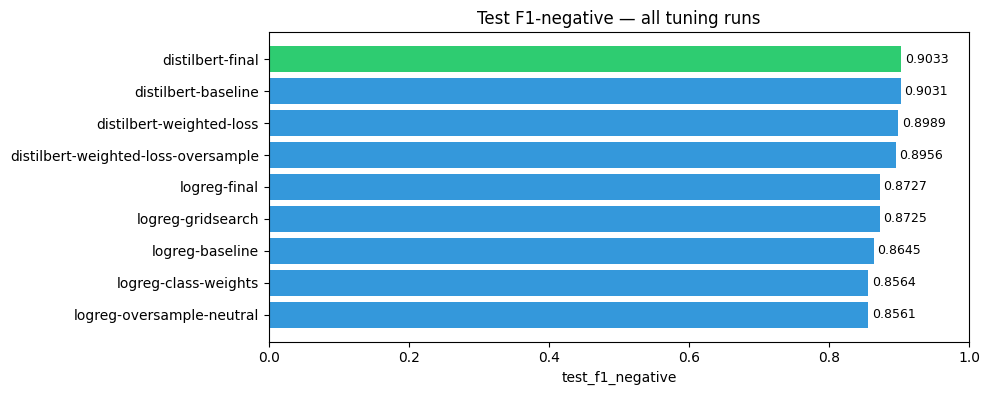

In [5]:
def plot_metric_comparison(df: pd.DataFrame, metric: str, title: str) -> None:
    plot_df = df.dropna(subset=[metric]).sort_values(metric, ascending=True)
    if plot_df.empty:
        print(f"No data for {metric}")
        return
    labels = plot_df["run_name"].tolist()
    values = plot_df[metric].tolist()
    colors = ["#2ecc71" if i == len(labels) - 1 else "#3498db" for i in range(len(labels))]
    fig, ax = plt.subplots(figsize=(10, max(3, len(labels) * 0.45)))
    ax.barh(labels, values, color=colors)
    ax.set_xlabel(metric)
    ax.set_title(title)
    ax.set_xlim(0, 1)
    for i, v in enumerate(values):
        ax.text(v + 0.005, i, f"{v:.4f}", va="center", fontsize=9)
    plt.tight_layout()
    plt.show()

plot_metric_comparison(
    pd.concat([
        logreg_runs.assign(family="tfidf-logreg"),
        distilbert_runs.assign(family="distilbert"),
    ]),
    "test_f1_negative",
    "Test F1-negative — all tuning runs",
)

## [4] MLflow Model Registry

All registered versions with current stage (`None`, `Staging`, `Production`).

In [6]:
registry = {
    name: cm.fetch_registry_versions(name, TRACKING_URI)
    for name in cm.REGISTERED_MODELS
}

registry_frames = []
for name, df in registry.items():
    if df.empty:
        continue
    show = df.copy()
    show["model"] = name
    registry_frames.append(show)

registry_df = pd.concat(registry_frames, ignore_index=True) if registry_frames else pd.DataFrame()
registry_df

,model,version,stage,run_id,run_name,test_f1_negative,oot_f1_negative,test_f1_macro,created
0,sentiment-baseline,1,Production,cb75b917e303477b902a1af703400081,bustling-hog-952,NaN,NaN,NaN,2026-06-09 07:53:42.790
1,sentiment-baseline,2,None,cb75b917e303477b902a1af703400081,bustling-hog-952,NaN,NaN,NaN,2026-06-09 07:59:54.969
2,sentiment-baseline,3,None,2caa4bcf701c4003a342a491531a796d,logreg-final,0.872747,0.863459,0.720847,2026-06-10 06:05:34.784
3,sentiment-distilbert,1,None,1f09f7ef88684c1c98e1400eaa5eaf24,distilbert-final,0.903260,0.891192,0.790500,2026-06-13 12:58:07.340


## [5] Promotion recommendations

Per `WORKFLOW.md`, promote the winner to **Staging** first so FastAPI shadow-deploy can compare it
against Production over two 6-hour cycles before manual promotion to Production.

In [7]:
recommendations = cm.recommend_promotions(registry, leaderboard)

for rec in recommendations:
    print(f"{rec.model_name} v{rec.version} ({rec.run_name})")
    print(f"  test F1-neg : {rec.test_f1_negative:.4f}")
    print(f"  action      : {rec.reason}")
    print()

sentiment-baseline v3 (logreg-final)
  test F1-neg : 0.8727
  action      : Registered for shadow comparison; leaderboard winner is distilbert (0.9033 vs 0.8727).

sentiment-distilbert v1 (distilbert-final)
  test F1-neg : 0.9033
  action      : Highest test F1-negative (0.9033) on the cross-family leaderboard. Promote to Staging for shadow deploy.



### Promote to Staging (manual step)

Run the cell below **only after** you agree with the recommendation above.
Set `PROMOTE = True` to transition the chosen version to `Staging`.

In [8]:
from mlflow.exceptions import MlflowException
from mlflow.tracking import MlflowClient

PROMOTE = False  # flip to True when ready

# Edit these if you want a different version than the recommendation.
STAGING_TARGETS = {
    "sentiment-distilbert": 1,   # distilbert-final — leaderboard winner
    "sentiment-baseline": 3,     # logreg-final — keep as Production baseline / shadow pair
}

client = MlflowClient(tracking_uri=TRACKING_URI)

if TRACKING_URI.startswith("file:"):
    raise RuntimeError(
        "Connected to local file store, but your registered models are on Docker MLflow. "
        "Run `docker compose up -d mlflow`, re-run cell [0], then retry promotion."
    )

available = {
    name: {int(v.version) for v in client.search_model_versions(f"name='{name}'")}
    for name in STAGING_TARGETS
}
missing = [
    f"{name} v{ver}"
    for name, ver in STAGING_TARGETS.items()
    if ver not in available.get(name, set())
]
if missing:
    raise RuntimeError(
        "These registry versions were not found at "
        f"{TRACKING_URI}: {', '.join(missing)}. "
        "Re-run cells [0]–[4] against Docker MLflow (http://localhost:5001)."
    )

if PROMOTE:
    for model_name, version in STAGING_TARGETS.items():
        client.transition_model_version_stage(
            name=model_name,
            version=str(version),
            stage="Staging",
            archive_existing_versions=False,
        )
        print(f"Promoted {model_name} v{version} -> Staging")
else:
    print("PROMOTE=False — review tables above, then set PROMOTE=True to transition stages.")
    for model_name, version in STAGING_TARGETS.items():
        mv = client.get_model_version(model_name, str(version))
        print(f"  {model_name} v{version}: current stage = {mv.current_stage or 'None'}")

PROMOTE=False — review tables above, then set PROMOTE=True to transition stages.
  sentiment-distilbert v1: current stage = None
  sentiment-baseline v3: current stage = None


## [6] Full metric detail (all splits)

Unformatted numeric table for copy/paste into reports.

In [9]:
detail_cols = ["run_name", "family", "run_id"] + cm.METRIC_COLS
all_runs = pd.concat([
    logreg_runs.assign(family="tfidf-logreg"),
    distilbert_runs.assign(family="distilbert"),
], ignore_index=True)
all_runs[[c for c in detail_cols if c in all_runs.columns]].sort_values(
    "test_f1_negative", ascending=False, na_position="last"
)

,run_name,family,run_id,val_f1_negative,val_recall_negative,val_precision_negative,val_f1_macro,test_f1_negative,test_recall_negative,test_precision_negative,test_f1_macro,oot_f1_negative,oot_recall_negative,oot_precision_negative,oot_f1_macro
5,distilbert-final,distilbert,1f09f7ef88684c1c98e1400eaa5eaf24,NaN,NaN,NaN,NaN,0.903260,0.927552,0.880208,0.790500,0.891192,0.922252,0.862155,0.784124
6,distilbert-baseline,distilbert,a8cebd6f87dc46f99ea0ba285d82053a,0.899123,0.901099,0.897155,0.787044,0.903050,0.909989,0.896216,0.796652,0.889778,0.894549,0.885057,0.793683
7,distilbert-weighted-loss,distilbert,b4471dcb05b145d5b2336f4057944ac0,0.893407,0.893407,0.893407,0.784334,0.898901,0.897914,0.899890,0.793807,0.889579,0.896336,0.882923,0.793498
8,distilbert-weighted-loss-oversample,distilbert,d528ed0482844a9285ab2386bac0de90,0.878075,0.902198,0.855208,0.769504,0.895587,0.913282,0.878564,0.785124,0.876736,0.902592,0.852321,0.775745
0,logreg-final,tfidf-logreg,2caa4bcf701c4003a342a491531a796d,NaN,NaN,NaN,NaN,0.872747,0.903403,0.844103,0.720847,0.863459,0.890080,0.838384,0.716203
1,logreg-gridsearch,tfidf-logreg,abf1fa6ba639478ba36cec7ed11e38b6,NaN,NaN,NaN,NaN,0.872476,0.901207,0.845520,0.721952,0.864583,0.890080,0.840506,0.718464
2,logreg-baseline,tfidf-logreg,8d4043aca18041e0a87753ea8ae9ee6a,0.863147,0.880220,0.846723,0.662208,0.864461,0.889133,0.841121,0.685290,0.857268,0.874888,0.840343,0.688166
3,logreg-class-weights,tfidf-logreg,1ea4d8042f50410d9b1ad7d7e36892c8,0.852814,0.865934,0.840085,0.736719,0.856371,0.870472,0.842721,0.750538,0.840820,0.861483,0.821124,0.736551
4,logreg-oversample-neutral,tfidf-logreg,0fc52b0def88473889fd8af92740d4a4,0.852389,0.872527,0.833158,0.735878,0.856077,0.881449,0.832124,0.754136,0.845458,0.877569,0.815615,0.739092
9,distilbert-lr-probe-5e-05,distilbert,0a6e83a9d6704f26bae037a91ede86f4,0.889381,0.883516,0.895323,0.790316,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
